In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sales = pd.read_csv("data/sales_train_evaluation.csv")
calendar = pd.read_csv("data/calendar.csv")

day_cols = [c for c in sales.columns if c.startswith("d_")]

# Top 10 sellers in store CA_1
store = sales[sales["store_id"] == "CA_1"].copy()
store["total_sold"] = store[day_cols].sum(axis=1)
top10 = store.nlargest(10, "total_sold")
print(top10[["item_id", "total_sold"]])

          item_id  total_sold
2314  FOODS_3_090      128855
2810  FOODS_3_586       88846
2476  FOODS_3_252       76055
2344  FOODS_3_120       63107
2937  FOODS_3_714       54617
2811  FOODS_3_587       52356
3029  FOODS_3_808       46094
2023  FOODS_2_197       41312
2304  FOODS_3_080       39673
2779  FOODS_3_555       38446


In [2]:
long = top10.melt(
    id_vars=["id", "item_id"],
    value_vars=day_cols,
    var_name="d",
    value_name="units"
)

# attach real dates and holiday info from the calendar
long = long.merge(calendar[["d", "date", "event_name_1", "snap_CA"]], on="d")
long["date"] = pd.to_datetime(long["date"])
long = long.sort_values(["item_id", "date"]).reset_index(drop=True)

print(long.shape)
long.head()

(19410, 7)


,id,item_id,d,units,date,event_name_1,snap_CA
0,FOODS_2_197_CA_1_evaluation,FOODS_2_197,d_1,38,2011-01-29,NaN,0
1,FOODS_2_197_CA_1_evaluation,FOODS_2_197,d_2,31,2011-01-30,NaN,0
2,FOODS_2_197_CA_1_evaluation,FOODS_2_197,d_3,14,2011-01-31,NaN,0
3,FOODS_2_197_CA_1_evaluation,FOODS_2_197,d_4,29,2011-02-01,NaN,1
4,FOODS_2_197_CA_1_evaluation,FOODS_2_197,d_5,24,2011-02-02,NaN,1


In [3]:
cutoff = long["date"].max() - pd.Timedelta(days=28)
train = long[long["date"] <= cutoff]
test  = long[long["date"] >  cutoff]
print("train days:", train["date"].nunique(), "| test days:", test["date"].nunique())

train days: 1913 | test days: 28


In [4]:
def seasonal_naive(train_units, horizon=28):
    last_week = train_units[-7:]                # final 7 days of training
    reps = int(np.ceil(horizon / 7))
    return np.tile(last_week, reps)[:horizon]   # repeat it 4 times

# error metric: on average, how many units off are we per day?
def mae(actual, forecast):
    return np.mean(np.abs(np.array(actual) - np.array(forecast)))

results = []
for item in long["item_id"].unique():
    tr = train[train["item_id"] == item]["units"].values
    te = test[test["item_id"] == item]["units"].values
    fc = seasonal_naive(tr)
    results.append({"item_id": item, "naive_mae": mae(te, fc)})

baseline = pd.DataFrame(results)
print(baseline)
print("\nAverage MAE:", baseline["naive_mae"].mean().round(2))

       item_id  naive_mae
0  FOODS_2_197   7.571429
1  FOODS_3_080   4.500000
2  FOODS_3_090  16.785714
3  FOODS_3_120  16.785714
4  FOODS_3_252   9.500000
5  FOODS_3_555   3.678571
6  FOODS_3_586   8.535714
7  FOODS_3_587   7.607143
8  FOODS_3_714   5.964286
9  FOODS_3_808   0.000000

Average MAE: 8.09


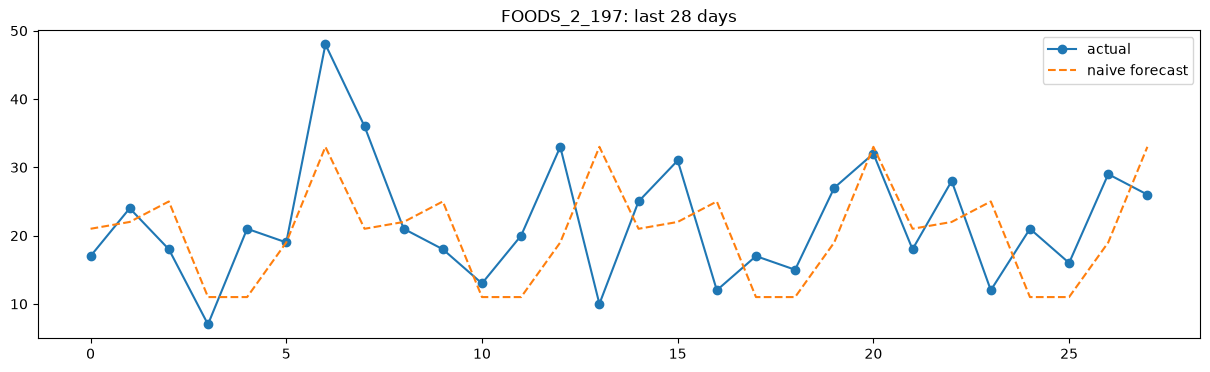

In [5]:
item = long["item_id"].unique()[0]
tr = train[train["item_id"] == item]["units"].values
te = test[test["item_id"] == item]["units"].values

plt.figure(figsize=(15, 4))
plt.plot(range(28), te, label="actual", marker="o")
plt.plot(range(28), seasonal_naive(tr), label="naive forecast", linestyle="--")
plt.title(f"{item}: last 28 days"); plt.legend(); plt.show()